# MLP S2 — Case Study: Electricity Demand Preprocessing

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/data_science_practice/blob/main/website/public/modules/ms2a-machine-learning-practice/challenges/mlp-s2-case-study.ipynb)

The task: predict the **daily electricity demand** of a region from the weather of the day
(humidity, wind, ten temperature stations, a weather condition) and an oil-price indicator.

The model is a plain `LinearRegression` and the score is the **mean squared error (MSE)** on a
5-fold **time-series split** (each fold is trained on the past and validated on the following
period). The model never changes: every improvement below comes from the preprocessing.

The order is the checklist of the exercise, one function per step:

1. inconsistencies
2. duplicates
3. missing values
4. categorical values
5. outliers
6. feature engineering
7. feature selection

Each step follows the same pattern: **what the data shows → the choice → the measured effect.**

This is the complete run of what the lab asks you to do yourself, on this dataset.

---

## 0. Setup

Colab already provides pandas, scikit-learn, matplotlib and requests; nothing to install.
Outside Colab, use an environment with the same packages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

---

## 1. Data collection

In [2]:
import requests

# URLs of the files
train_data_url = 'https://www.raphaelcousin.com/modules/data-science-practice/module5/exercise/module5_exercise_train.csv'
test_data_url = 'https://www.raphaelcousin.com/modules/data-science-practice/module5/exercise/module5_exercise_test.csv'

# Function to download a file
def download_file(url, file_name):
    response = requests.get(url)
    response.raise_for_status()  # Ensure we notice bad responses
    with open(file_name, 'wb') as file:
        file.write(response.content)
    print(f'Downloaded {file_name} from {url}')

# Downloading the files
download_file(train_data_url, 'module5_exercise_train.csv')
download_file(test_data_url, 'module5_exercise_test.csv')

Downloaded module5_exercise_train.csv from https://www.raphaelcousin.com/modules/data-science-practice/module5/exercise/module5_exercise_train.csv
Downloaded module5_exercise_test.csv from https://www.raphaelcousin.com/modules/data-science-practice/module5/exercise/module5_exercise_test.csv


In [3]:
df_train = pd.read_csv("module5_exercise_train.csv", sep=",")
df_test = pd.read_csv("module5_exercise_test.csv", sep=",")

print("train:", df_train.shape, "  test:", df_test.shape)
df_train.head()

train: (1909, 16)   test: (365, 15)


,date,weather_condition,humidity,wind_speed,oil_brent_price_indicator,temperature_station1,temperature_station2,temperature_station3,temperature_station4,temperature_station5,temperature_station6,temperature_station7,temperature_station8,temperature_station9,temperature_station10,electricity_demand
0,2015-01-08,Cloudy,69.304377,27.74 km/h,Moderate,0.369411,NaN,0.159977,0.118224,-0.444455,0.313675,0.106192,0.369430,1.279470,-0.384661,273.511353
1,2015-01-09,Sunny,55.955975,21.78 km/h,Moderate,2.009903,NaN,1.617242,NaN,2.160063,2.515627,1.867474,1.953165,1.878233,1.582365,258.827085
2,2015-01-10,Rainy,62.701614,6.83 m/s,Moderate,-2.603544,-2.422001,-3.685819,-2.392354,-1.936704,-2.950332,-3.074828,-2.698650,-2.354860,-2.770883,302.535033
3,2015-01-11,Snowy,60.375001,5.79 m/s,Moderate,-3.789836,-3.974054,-3.217545,-4.397143,-3.375188,-3.650454,-5.004991,-3.233724,-4.227899,NaN,296.270989
4,2015-01-12,Snowy,NaN,25.14 km/h,High,-2.405522,-2.161129,-2.880773,-2.587199,NaN,NaN,NaN,NaN,-2.790422,-2.033098,323.498090


`df_train` holds 1,909 daily rows with the target `electricity_demand`; `df_test` holds 365 rows
without it. Everything below is done on `df_train`: the validation strategy replaces the test file.

---

## 2. Data analysis

The checklist, in order:

- Inconsistencies
- Duplicates (`data.duplicated().sum()`)
- Missing values (`data.isnull().sum()`)
- Categorical
- Outliers
- Feature Engineering
- Feature Selection and/or Dimensionality Reduction

First, what pandas made of each column.

In [4]:
summary = pd.DataFrame({
    "dtype": df_train.dtypes.astype(str),
    "missing": df_train.isnull().sum(),
    "missing_share": df_train.isnull().mean().round(3),
    "distinct": df_train.nunique(),
})
summary

,dtype,missing,missing_share,distinct
date,str,0,0.000,1819
weather_condition,str,24,0.013,4
humidity,float64,96,0.050,1727
wind_speed,str,90,0.047,1172
oil_brent_price_indicator,str,0,0.000,5
temperature_station1,float64,285,0.149,1548
temperature_station2,float64,275,0.144,1556
temperature_station3,float64,289,0.151,1550
temperature_station4,float64,277,0.145,1558
temperature_station5,float64,279,0.146,1550


**What we see.** Three columns are text: `date`, `weather_condition`, `oil_brent_price_indicator`,
and `wind_speed`, which should be a number. Every temperature station is missing about 15% of the
days, humidity and wind about 5%, the weather condition 1%. `date` has 1,819 distinct values for
1,909 rows: some dates appear twice.

#### Inconsistencies

In [5]:
# wind_speed is text because the unit is written inside the value, and the unit is not always the same
print(df_train["wind_speed"].dropna().head(8).tolist())
units = df_train["wind_speed"].dropna().str.split(" ").str[1]
print("units in train:", units.value_counts().to_dict())
print("units in test: ", df_test["wind_speed"].dropna().str.split(" ").str[1].value_counts().to_dict())

['27.74 km/h', '21.78 km/h', '6.83 m/s', '5.79 m/s', '25.14 km/h', '28.75 km/h', '28.75 km/h', '19.97 km/h']
units in train: {'m/s': 923, 'km/h': 896}
units in test:  {'km/h': 176, 'm/s': 172}


Half the wind speeds are in km/h and half in m/s. As a number, `27.74 km/h` (7.7 m/s) would
look three times windier than `9.5 m/s`. The values must be brought to one unit before anything
else is measured on this column.

#### Duplicates

In [6]:
print("duplicated rows:", df_train.duplicated().sum())
print("duplicated dates:", df_train["date"].duplicated().sum())
# a duplicated date is an exact copy of the whole row
dup_date = df_train.loc[df_train["date"].duplicated(), "date"].iloc[0]
df_train[df_train["date"] == dup_date]

duplicated rows: 90
duplicated dates: 90


,date,weather_condition,humidity,wind_speed,oil_brent_price_indicator,temperature_station1,temperature_station2,temperature_station3,temperature_station4,temperature_station5,temperature_station6,temperature_station7,temperature_station8,temperature_station9,temperature_station10,electricity_demand
5,2015-01-13,Cloudy,58.649834,28.75 km/h,High,-5.037719,-4.891658,-4.655657,-5.545906,NaN,-5.323173,-5.771092,NaN,-4.554718,-4.719306,303.623789
6,2015-01-13,Cloudy,58.649834,28.75 km/h,High,-5.037719,-4.891658,-4.655657,-5.545906,NaN,-5.323173,-5.771092,NaN,-4.554718,-4.719306,303.623789


The 90 duplicated dates are 90 exact copies of an existing row (same weather, same demand).
A copied row counts twice in the regression and, in a time-series split, can sit on both sides of
a fold boundary. They are removed.

#### Missing values

In [7]:
temperature_cols = [c for c in df_train.columns if c.startswith("temperature_station")]

# the ten stations measure the same regional temperature: their correlation is above 0.99
corr = df_train[temperature_cols].corr()
print("smallest correlation between two stations:", round(corr.values[np.triu_indices(10, k=1)].min(), 4))

n_available = df_train[temperature_cols].notna().sum(axis=1)
print("days with all 10 stations:", (n_available == 10).sum(),
      "| days with no station at all:", (n_available == 0).sum(),
      "| median number of stations available per day:", int(n_available.median()))

smallest correlation between two stations: 0.9977
days with all 10 stations: 381 | days with no station at all: 0 | median number of stations available per day: 9


Each station is missing 15% of the days, but never all ten on the same day: on every day at least
some stations report, and they agree to three decimals. A missing station can therefore be filled
with the mean of the stations that reported that day, which is a far better guess than the median
of the column over five years.

For humidity and wind speed there is no such twin column; the median of the training rows is the
fallback. For the weather condition, a missing day takes the previous day's value (weather
persists from one day to the next), which needs no statistic learned from the data.

#### Categorical values

In [8]:
for col in ["weather_condition", "oil_brent_price_indicator"]:
    print(col, "->", df_train[col].value_counts(dropna=False).to_dict())

weather_condition -> {'Sunny': 574, 'Rainy': 574, 'Cloudy': 563, 'Snowy': 174, nan: 24}
oil_brent_price_indicator -> {'Moderate': 711, 'High': 559, 'Low': 377, 'Very High': 190, 'Very Low': 72}


`weather_condition` has four categories with no natural order: one column per category (one-hot).
`oil_brent_price_indicator` is an ordered scale, *Very Low < Low < Moderate < High < Very High*:
one integer column keeps the order and costs one coefficient instead of four. The category lists
are written down explicitly so that train and validation always get the same columns, whatever
categories a given fold happens to contain.

#### Outliers

In [9]:
df_train[["humidity", "electricity_demand"]].describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]).round(2)

,humidity,electricity_demand
count,1813.00,1909.00
mean,115.96,106.38
std,1658.23,5115.89
min,32.81,-223288.77
0.1%,35.23,108.69
1%,37.18,131.18
50%,62.02,214.48
99%,79.74,340.96
99.9%,9471.10,364.45
max,50000.00,387.74


In [10]:
print("humidity above 100%:")
print(df_train.loc[df_train["humidity"] > 100, ["date", "humidity"]])
print()
print("electricity demand at or below 0:")
print(df_train.loc[df_train["electricity_demand"] <= 0, ["date", "electricity_demand", "temperature_station1"]])

humidity above 100%:
            date  humidity
1022  2017-09-13   50000.0
1509  2018-12-18   50000.0

electricity demand at or below 0:
            date  electricity_demand  temperature_station1
1029  2017-09-20      -223288.771683              5.706528


Relative humidity cannot exceed 100%: the two values of 50,000 are not measurements. They become
missing and are imputed like any other gap.

One day has a demand of **−223,289** where the rest of the series lives between 100 and 400. A
negative demand is impossible, and a single value of that size dominates a squared error: the
whole MSE of the fold that contains it is that one row. The row is dropped from the training data
(the target is wrong, so there is nothing to learn from it). It is not clipped to 0: a 0 would still
be a false value, 200 below every real day.

The plot below shows both problems on the raw series.

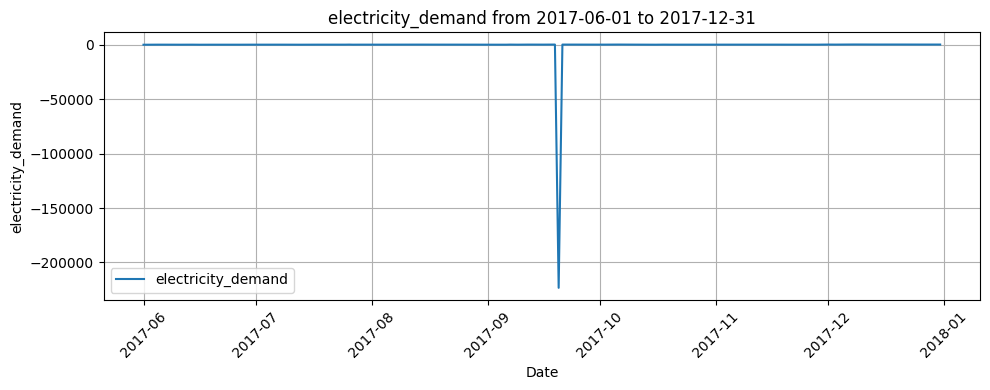

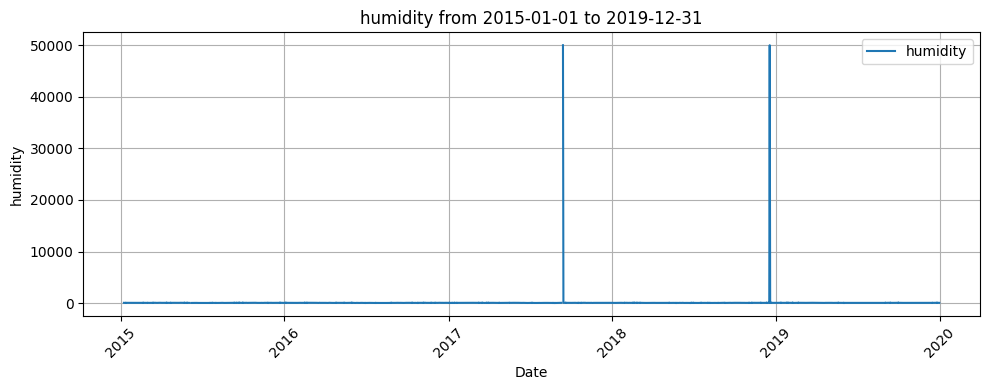

In [11]:
def plot_feature_over_time(df, feature, date_id_start, date_id_end):
    df_filtered = df[(df['date'] >= date_id_start) & (df['date'] <= date_id_end)]

    if feature not in df_filtered.columns:
        print(f"Feature '{feature}' not found in the DataFrame.")
        return

    plt.figure(figsize=(10, 4))
    plt.plot(df_filtered['date'], df_filtered[feature], label=feature, linestyle='-')
    plt.xlabel('Date')
    plt.ylabel(feature)
    plt.title(f'{feature} from {date_id_start} to {date_id_end}')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


data = df_train.copy()
data['date'] = pd.to_datetime(data['date'])
plot_feature_over_time(data, 'electricity_demand', '2017-06-01', '2017-12-31')
plot_feature_over_time(data, 'humidity', '2015-01-01', '2019-12-31')

#### What drives the demand

Before engineering features, look at how the target moves with the columns. The temperature is
the obvious candidate; the calendar and the categories are the others.

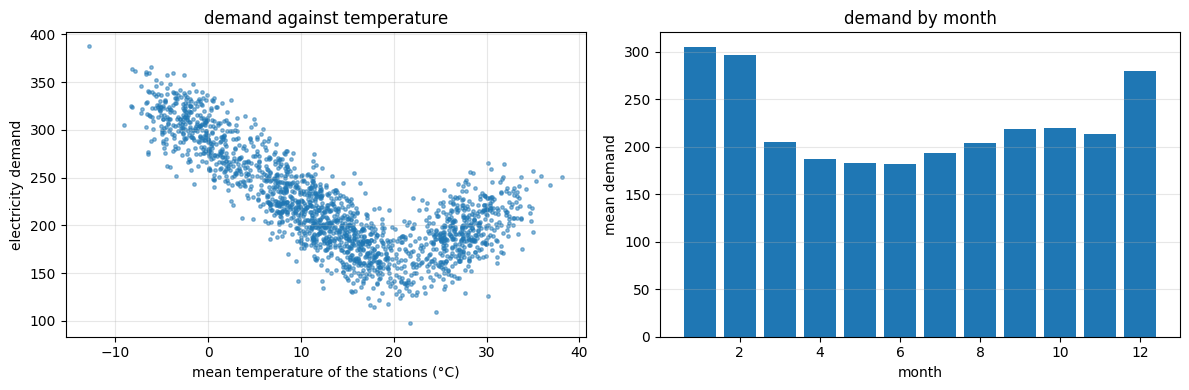

correlation(temperature, demand): -0.734


In [12]:
clean = df_train.drop_duplicates().copy()
clean = clean[clean["electricity_demand"] > 0]
clean["date"] = pd.to_datetime(clean["date"])
clean["temperature_mean"] = clean[temperature_cols].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(clean["temperature_mean"], clean["electricity_demand"], s=6, alpha=0.5)
axes[0].set_xlabel("mean temperature of the stations (°C)")
axes[0].set_ylabel("electricity demand")
axes[0].set_title("demand against temperature")
axes[0].grid(alpha=0.3)

monthly = clean.groupby(clean["date"].dt.month)["electricity_demand"].mean()
axes[1].bar(monthly.index, monthly.values)
axes[1].set_xlabel("month")
axes[1].set_ylabel("mean demand")
axes[1].set_title("demand by month")
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("correlation(temperature, demand):", round(clean["temperature_mean"].corr(clean["electricity_demand"]), 3))

The relation is a **V**: demand falls as it gets warmer until about 20 °C, then rises again
(heating on cold days, cooling on hot days). A straight line through this cloud fits neither
side. The usual way to give a linear model this shape is the two *degree-day* features of energy
accounting: how many degrees below a heating threshold, how many degrees above a cooling
threshold.

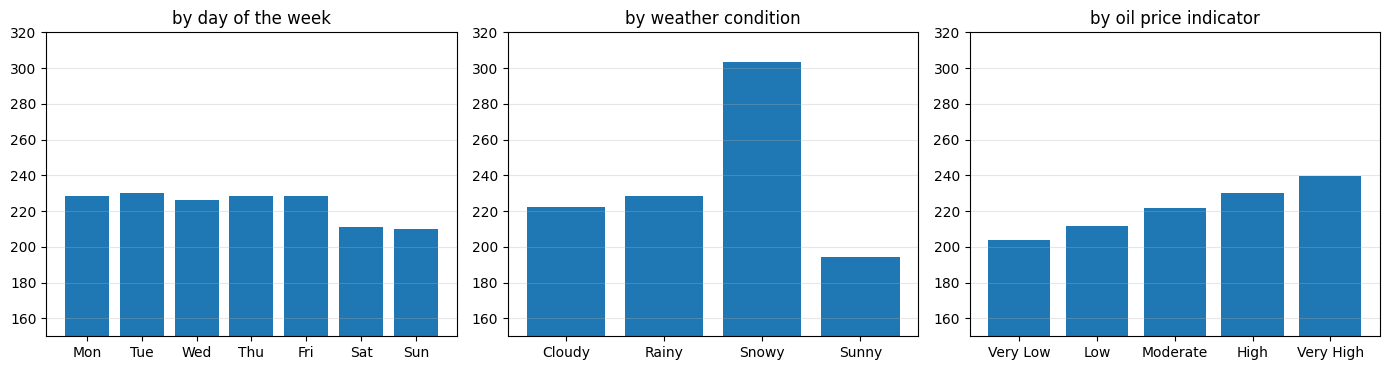

In [13]:
by_weekday = clean.groupby(clean["date"].dt.dayofweek)["electricity_demand"].mean()
by_weather = clean.groupby("weather_condition")["electricity_demand"].mean()
oil_order = ["Very Low", "Low", "Moderate", "High", "Very High"]
by_oil = clean.groupby("oil_brent_price_indicator")["electricity_demand"].mean().reindex(oil_order)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], by_weekday.values)
axes[0].set_title("by day of the week")
axes[1].bar(by_weather.index, by_weather.values)
axes[1].set_title("by weather condition")
axes[2].bar(by_oil.index, by_oil.values)
axes[2].set_title("by oil price indicator")
for ax in axes:
    ax.set_ylim(150, 320)
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Weekends run about 15 below weekdays. Snowy days are far above the others, but snow comes with
cold, so most of that is the temperature; sunny days sit below. The oil indicator is monotonic:
the higher the indicator, the higher the demand, which is what an ordinal encoding assumes.
The year-to-year drift is small (219 in 2015 to 227 in 2019).

Everything needed to write the seven functions is now on the table.

---

## 3. Data preprocessing evaluation strategy

`evaluate_pipeline` is the template's function with one addition: it takes the list of steps to
apply. Every step has the same signature, `step(X_train, y_train, X_val=None)`, and returns
`(X_train, y_train, X_val)`.

- Steps that learn nothing from the data (a unit conversion, a fixed category list, a rule
  on impossible values, a date feature) are applied **once, before the split**.
- Steps that learn a statistic (the medians used to fill gaps) are applied **inside each fold**,
  fitted on the fold's training rows and applied to its validation rows. Otherwise the
  validation rows would leak into the statistic.

The split is `TimeSeriesSplit(n_splits=5)` on the rows in date order, so each fold validates on
a period that comes after its training period. The model is `LinearRegression()`; the score is
the MSE, averaged over the folds.

In [14]:
def evaluate_pipeline(X, y, steps_before=(), steps_in_fold=(), n_splits=5, verbose=True):
    """Apply `steps_before` once, then cross-validate `steps_in_fold` + LinearRegression."""
    X, y = X.copy(), y.copy()
    for step in steps_before:                   # no learning: once, on everything
        X, y, _ = step(X, y)

    model = LinearRegression()
    tscv = TimeSeriesSplit(n_splits=n_splits)
    train_scores, val_scores = [], []

    for fold, (train_index, val_index) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_index].copy(), X.iloc[val_index].copy()
        y_train, y_val = y.iloc[train_index].copy(), y.iloc[val_index].copy()

        for step in steps_in_fold:              # learning: fitted on the fold's train rows only
            X_train, y_train, X_val = step(X_train, y_train, X_val)

        model.fit(X_train, y_train)
        train_mse = mean_squared_error(y_train, model.predict(X_train))
        val_mse = mean_squared_error(y_val, model.predict(X_val))
        train_scores.append(train_mse)
        val_scores.append(val_mse)
        if verbose:
            print(f"Fold {fold + 1} Train MSE: {train_mse:,.1f}   Validation MSE: {val_mse:,.1f}")

    if verbose:
        print(f"\nTrain MSE      mean {np.mean(train_scores):,.1f}   min {np.min(train_scores):,.1f}   max {np.max(train_scores):,.1f}")
        print(f"Validation MSE mean {np.mean(val_scores):,.1f}   min {np.min(val_scores):,.1f}   max {np.max(val_scores):,.1f}")
    return {"train_mse": float(np.mean(train_scores)), "val_mse": float(np.mean(val_scores)),
            "val_mse_max": float(np.max(val_scores)), "n_features": int(X_train.shape[1])}


results = []

def record(name, res):
    results.append({"step": name, **res})
    return pd.DataFrame(results).set_index("step").round(1)


# Prepare X and y
X = df_train.drop(columns=['electricity_demand'])
y = df_train['electricity_demand']

---

## 4. The seven steps, measured

### Step 0 — the baseline

The least that runs: keep the numeric columns as pandas read them, put 0 in every empty cell,
drop the text. No knowledge of the data at all.

In [15]:
def baseline_numeric(X_train, y_train, X_val=None):
    numeric = X_train.select_dtypes(include="number").columns
    X_train = X_train[numeric].fillna(0)
    X_val = X_val[numeric].fillna(0) if X_val is not None else None
    return X_train, y_train, X_val


res = evaluate_pipeline(X, y, steps_before=[baseline_numeric])
record("0 baseline: numeric as read, NaN -> 0", res)

Fold 1 Train MSE: 1,190.2   Validation MSE: 1,584.8
Fold 2 Train MSE: 1,357.4   Validation MSE: 1,368.0
Fold 3 Train MSE: 1,311.0   Validation MSE: 157,378,351.8
Fold 4 Train MSE: 39,182,321.9   Validation MSE: 90,877.2
Fold 5 Train MSE: 31,364,589.8   Validation MSE: 39,327.1

Train MSE      mean 14,110,154.0   min 1,190.2   max 39,182,321.9
Validation MSE mean 31,502,301.8   min 1,368.0   max 157,378,351.8


,train_mse,val_mse,val_mse_max,n_features
step,,,,
"0 baseline: numeric as read, NaN -> 0",14110154.0,31502301.8,157378351.8,11


One fold has a validation MSE in the hundreds of millions: it is the fold whose validation period
contains the −223,289 demand. Squared, that single row is worth more than every other row
together. Nothing measured before that row is handled means anything, but the checklist is
followed in order, and the outlier step (5) is where it goes.

### Step 1 — Handle inconsistencies

**Information.** `wind_speed` mixes km/h and m/s inside the text. `date` is text.
**Choice.** Parse the number and the unit; convert km/h to m/s (÷ 3.6). Parse the date. Nothing is
learned from the data, so the step runs once before the split.

In [16]:
def handle_inconsistencies(X_train, y_train, X_val=None):
    def convert_wind_speed(wind_speed):
        if pd.isnull(wind_speed):
            return np.nan
        value, unit = wind_speed.split(' ')
        value = float(value)
        if unit == 'km/h':
            return value / 3.6
        return value                        # already in m/s

    def fix(frame):
        frame = frame.copy()
        frame['wind_speed'] = frame['wind_speed'].apply(convert_wind_speed)
        frame['date'] = pd.to_datetime(frame['date'])
        return frame

    X_train = fix(X_train)
    X_val = fix(X_val) if X_val is not None else None
    return X_train, y_train, X_val


steps = [handle_inconsistencies, baseline_numeric]
res = evaluate_pipeline(X, y, steps_before=steps, verbose=False)
record("1 + inconsistencies: wind speed in m/s, date parsed", res)

,train_mse,val_mse,val_mse_max,n_features
step,,,,
"0 baseline: numeric as read, NaN -> 0",14110154.0,31502301.8,157378351.8,11
"1 + inconsistencies: wind speed in m/s, date parsed",14092239.3,31517652.3,157347984.9,12


### Step 2 — Handle duplicates

**Information.** 90 rows are exact copies of another row (same date, same values).
**Choice.** Drop them, and drop the matching target rows through the index. A copy carries no
information and doubles the weight of its day.

In [17]:
def handle_duplicates(X_train, y_train, X_val=None):
    keep = ~X_train.duplicated()
    X_train = X_train[keep]
    y_train = y_train.loc[X_train.index]
    return X_train, y_train, X_val          # validation rows are never dropped


steps = [handle_inconsistencies, handle_duplicates, baseline_numeric]
res = evaluate_pipeline(X, y, steps_before=steps, verbose=False)
record("2 + duplicates removed", res)

,train_mse,val_mse,val_mse_max,n_features
step,,,,
"0 baseline: numeric as read, NaN -> 0",14110154.0,31502301.8,157378351.8,11
"1 + inconsistencies: wind speed in m/s, date parsed",14092239.3,31517652.3,157347984.9,12
2 + duplicates removed,14787464.6,33073414.8,165108537.9,12


### Step 3 — Handle missing values

**Information.** The ten stations measure one temperature and never all fail on the same day;
humidity and wind have no twin column; the weather condition persists from one day to the next.
**Choice.**
- a missing station takes the mean of the stations that reported that day (no learning);
- a remaining gap in a numeric column takes the **median of the training rows** — learned, so
  this step runs inside the fold;
- a missing weather condition takes the previous day's value (`ffill`), then the next day's for a
  gap at the very start (`bfill`).

This replaces the `NaN -> 0` of the baseline. A 0 in a temperature column was a −13 °C-like cold
day; a 0 in humidity was drier than any real day.

In [18]:
def handle_missing_values(X_train, y_train, X_val=None):
    stations = [c for c in X_train.columns if c.startswith("temperature_station")]

    def fill_stations(frame):
        frame = frame.copy()
        row_mean = frame[stations].mean(axis=1)             # the other stations, same day
        for c in stations:
            frame[c] = frame[c].fillna(row_mean)
        return frame

    def fill_weather(frame):
        frame = frame.copy()
        if "weather_condition" in frame.columns:
            frame["weather_condition"] = frame["weather_condition"].ffill().bfill()
        return frame

    X_train = fill_weather(fill_stations(X_train))
    numeric = X_train.select_dtypes(include="number").columns
    medians = X_train[numeric].median()                     # learned on the training rows only
    X_train[numeric] = X_train[numeric].fillna(medians)

    if X_val is not None:
        X_val = fill_weather(fill_stations(X_val))
        X_val[numeric] = X_val[numeric].fillna(medians)     # the same medians, not the validation ones
    return X_train, y_train, X_val


def drop_text(X_train, y_train, X_val=None):
    """Until step 4: keep the numeric columns (no more NaN -> 0)."""
    numeric = X_train.select_dtypes(include="number").columns
    return X_train[numeric], y_train, (X_val[numeric] if X_val is not None else None)


steps = [handle_inconsistencies, handle_duplicates]
res = evaluate_pipeline(X, y, steps_before=steps, steps_in_fold=[handle_missing_values, drop_text], verbose=False)
record("3 + missing values: station mean, train medians, weather ffill", res)

,train_mse,val_mse,val_mse_max,n_features
step,,,,
"0 baseline: numeric as read, NaN -> 0",14110154.0,31502301.8,157378351.8,11
"1 + inconsistencies: wind speed in m/s, date parsed",14092239.3,31517652.3,157347984.9,12
2 + duplicates removed,14787464.6,33073414.8,165108537.9,12
"3 + missing values: station mean, train medians, weather ffill",14701109.4,33825106.6,168432805.7,12


### Step 4 — Handle categorical values

**Information.** `weather_condition`: four unordered categories. `oil_brent_price_indicator`: five
ordered levels, and the demand rises with the level.
**Choice.** One-hot columns for the weather with a fixed list of categories, so every fold produces
the same columns; the oil indicator becomes its rank, 0 to 4. The lists are constants, not learned,
so the step runs before the split.

In [19]:
WEATHER_CATEGORIES = ["Cloudy", "Rainy", "Snowy", "Sunny"]
OIL_ORDER = {"Very Low": 0, "Low": 1, "Moderate": 2, "High": 3, "Very High": 4}


def handle_categorical(X_train, y_train, X_val=None):
    def encode(frame):
        frame = frame.copy()
        for cat in WEATHER_CATEGORIES:
            frame[f"weather_{cat}"] = (frame["weather_condition"] == cat).astype(float)
        frame["oil_price_level"] = frame["oil_brent_price_indicator"].map(OIL_ORDER).astype(float)
        return frame.drop(columns=["weather_condition", "oil_brent_price_indicator"])

    X_train = encode(X_train)
    X_val = encode(X_val) if X_val is not None else None
    return X_train, y_train, X_val


# the weather one-hot must be computed after the weather gaps are filled: it runs in the fold, after step 3
steps_before = [handle_inconsistencies, handle_duplicates]
steps_in_fold = [handle_missing_values, handle_categorical, drop_text]
res = evaluate_pipeline(X, y, steps_before=steps_before, steps_in_fold=steps_in_fold, verbose=False)
record("4 + categorical: weather one-hot, oil indicator ordinal", res)

,train_mse,val_mse,val_mse_max,n_features
step,,,,
"0 baseline: numeric as read, NaN -> 0",14110154.0,31502301.8,157378351.8,11
"1 + inconsistencies: wind speed in m/s, date parsed",14092239.3,31517652.3,157347984.9,12
2 + duplicates removed,14787464.6,33073414.8,165108537.9,12
"3 + missing values: station mean, train medians, weather ffill",14701109.4,33825106.6,168432805.7,12
"4 + categorical: weather one-hot, oil indicator ordinal",14663183.9,35736254.6,177770220.1,17


### Step 5 — Handle outliers

**Information.** Two humidity values of 50,000 (impossible above 100%); one demand of −223,289
(impossible below 0), which alone sets the MSE of its fold.
**Choice.** Humidity above 100 becomes missing and is filled by step 3. The row with the impossible
demand is dropped from the training data: a wrong target teaches nothing, and clipping it to 0
would replace one false value with another. Validation rows are never dropped, so the fold that
contains that day still pays for it in the table until this step: after it, the row is gone
from both sides because the rules are applied before the split.

The real extremes stay: a demand of 388 on the coldest day and a temperature of −13 °C are
real days of this series, not errors.

In [20]:
def handle_outliers(X_train, y_train, X_val=None):
    def fix_humidity(frame):
        frame = frame.copy()
        frame.loc[frame["humidity"] > 100, "humidity"] = np.nan     # impossible, treated as missing
        return frame

    X_train = fix_humidity(X_train)
    keep = y_train > 0                                              # an impossible target: drop the row
    X_train, y_train = X_train[keep], y_train[keep]
    X_val = fix_humidity(X_val) if X_val is not None else None
    return X_train, y_train, X_val


steps_before = [handle_inconsistencies, handle_duplicates, handle_outliers]
steps_in_fold = [handle_missing_values, handle_categorical, drop_text]
res = evaluate_pipeline(X, y, steps_before=steps_before, steps_in_fold=steps_in_fold)
record("5 + outliers: humidity > 100 -> NaN, impossible demand row dropped", res)

Fold 1 Train MSE: 719.2   Validation MSE: 1,291.0
Fold 2 Train MSE: 956.4   Validation MSE: 1,059.0
Fold 3 Train MSE: 946.1   Validation MSE: 1,230.1
Fold 4 Train MSE: 1,011.7   Validation MSE: 1,021.9
Fold 5 Train MSE: 1,010.3   Validation MSE: 913.2

Train MSE      mean 928.7   min 719.2   max 1,011.7
Validation MSE mean 1,103.1   min 913.2   max 1,291.0


,train_mse,val_mse,val_mse_max,n_features
step,,,,
"0 baseline: numeric as read, NaN -> 0",14110154.0,31502301.8,157378351.8,11
"1 + inconsistencies: wind speed in m/s, date parsed",14092239.3,31517652.3,157347984.9,12
2 + duplicates removed,14787464.6,33073414.8,165108537.9,12
"3 + missing values: station mean, train medians, weather ffill",14701109.4,33825106.6,168432805.7,12
"4 + categorical: weather one-hot, oil indicator ordinal",14663183.9,35736254.6,177770220.1,17
"5 + outliers: humidity > 100 -> NaN, impossible demand row dropped",928.7,1103.1,1291.0,17


The MSE falls from hundreds of millions to about a thousand. Steps 1 to 4 were invisible behind the
outlier; re-measured with the outlier rule applied first, each one shows its real contribution:

In [21]:
ladder_without_outlier = []
for name, before, in_fold in [
    ("baseline + outlier rule", [handle_outliers, baseline_numeric], []),
    ("+ inconsistencies", [handle_inconsistencies, handle_outliers, baseline_numeric], []),
    ("+ duplicates", [handle_inconsistencies, handle_duplicates, handle_outliers, baseline_numeric], []),
    ("+ missing values", [handle_inconsistencies, handle_duplicates, handle_outliers], [handle_missing_values, drop_text]),
    ("+ categorical", [handle_inconsistencies, handle_duplicates, handle_outliers], [handle_missing_values, handle_categorical, drop_text]),
]:
    r = evaluate_pipeline(X, y, steps_before=before, steps_in_fold=in_fold, verbose=False)
    ladder_without_outlier.append({"step": name, **r})
pd.DataFrame(ladder_without_outlier).set_index("step").round(1)

,train_mse,val_mse,val_mse_max,n_features
step,,,,
baseline + outlier rule,1308.9,1430.0,1586.5,11
+ inconsistencies,1296.9,1428.9,1585.4,12
+ duplicates,1288.7,1415.9,1514.4,12
+ missing values,1150.0,1348.5,1558.6,12
+ categorical,928.7,1103.1,1291.0,17


Read top to bottom: the unit conversion makes wind usable, the duplicates cost little, the
imputation of the stations by their neighbours and of the gaps by the training medians is worth
a lot more than `NaN -> 0`, and the two encodings add the weather and the oil level.

### Step 6 — Feature engineering

**Information.** Demand against temperature is a V with its minimum near 20 °C; weekends are
lower; the months carry the season; the level drifts slightly over the years.
**Choice.** Give the straight line the shape it cannot make itself:
- `temperature_mean`: the mean of the ten stations (one clean signal instead of ten copies);
- `heating_degrees = max(0, 18 - T)` and `cooling_degrees = max(0, T - 24)`: the two arms of the V,
  with the flat bottom between 18 and 24 °C (the usual thresholds of degree-day accounting);
- `is_weekend`, and one column per weekday;
- the season as `sin` and `cos` of the day of the year (a smooth annual cycle in two columns);
- `year` as a number, for the drift.

All of it is computed from the row's own columns, so the step runs before the split.

In [22]:
def feature_engineering(X_train, y_train, X_val=None):
    stations = [c for c in X_train.columns if c.startswith("temperature_station")]

    def build(frame):
        frame = frame.copy()
        T = frame[stations].mean(axis=1)
        frame["temperature_mean"] = T
        frame["heating_degrees"] = np.maximum(0, 18 - T)
        frame["cooling_degrees"] = np.maximum(0, T - 24)
        d = frame["date"]
        frame["is_weekend"] = (d.dt.dayofweek >= 5).astype(float)
        for k in range(7):
            frame[f"weekday_{k}"] = (d.dt.dayofweek == k).astype(float)
        day_of_year = d.dt.dayofyear
        frame["season_sin"] = np.sin(2 * np.pi * day_of_year / 365.25)
        frame["season_cos"] = np.cos(2 * np.pi * day_of_year / 365.25)
        frame["year"] = d.dt.year.astype(float)
        return frame

    X_train = build(X_train)
    X_val = build(X_val) if X_val is not None else None
    return X_train, y_train, X_val


# the mean temperature needs complete stations: the step runs in the fold, after the imputation
steps_before = [handle_inconsistencies, handle_duplicates, handle_outliers]
steps_in_fold = [handle_missing_values, handle_categorical, feature_engineering, drop_text]
res = evaluate_pipeline(X, y, steps_before=steps_before, steps_in_fold=steps_in_fold)
record("6 + feature engineering: degree days, calendar, season, year", res)

Fold 1 Train MSE: 254.7   Validation MSE: 363.3
Fold 2 Train MSE: 291.9   Validation MSE: 346.9
Fold 3 Train MSE: 297.7   Validation MSE: 310.6
Fold 4 Train MSE: 299.2   Validation MSE: 315.8
Fold 5 Train MSE: 301.1   Validation MSE: 320.5

Train MSE      mean 288.9   min 254.7   max 301.1
Validation MSE mean 331.4   min 310.6   max 363.3


,train_mse,val_mse,val_mse_max,n_features
step,,,,
"0 baseline: numeric as read, NaN -> 0",14110154.0,31502301.8,157378351.8,11
"1 + inconsistencies: wind speed in m/s, date parsed",14092239.3,31517652.3,157347984.9,12
2 + duplicates removed,14787464.6,33073414.8,165108537.9,12
"3 + missing values: station mean, train medians, weather ffill",14701109.4,33825106.6,168432805.7,12
"4 + categorical: weather one-hot, oil indicator ordinal",14663183.9,35736254.6,177770220.1,17
"5 + outliers: humidity > 100 -> NaN, impossible demand row dropped",928.7,1103.1,1291.0,17
"6 + feature engineering: degree days, calendar, season, year",288.9,331.4,363.3,31


The V of the temperature is the big one. A quick check of which part paid: the same pipeline
with only the degree days, only the calendar, and both.

In [23]:
def only(columns_keep):
    def step(X_train, y_train, X_val=None):
        cols = [c for c in X_train.columns if c in columns_keep or not any(
            c.startswith(p) for p in ("heating_", "cooling_", "temperature_mean", "is_weekend", "weekday_", "season_", "year"))]
        return X_train[cols], y_train, (X_val[cols] if X_val is not None else None)
    return step

checks = []
for name, keep in [("degree days only", ["temperature_mean", "heating_degrees", "cooling_degrees"]),
                   ("calendar only (weekday, season, year)", ["is_weekend"] + [f"weekday_{k}" for k in range(7)] + ["season_sin", "season_cos", "year"])]:
    r = evaluate_pipeline(X, y, steps_before=steps_before,
                          steps_in_fold=[handle_missing_values, handle_categorical, feature_engineering, drop_text, only(keep)],
                          verbose=False)
    checks.append({"variant": name, **r})
pd.DataFrame(checks).set_index("variant").round(1)

,train_mse,val_mse,val_mse_max,n_features
variant,,,,
degree days only,344.4,395.9,416.1,20
"calendar only (weekday, season, year)",834.7,1046.2,1169.4,28


### Step 7 — Feature selection and dimensionality reduction

**Information.** The ten stations are ten copies of `temperature_mean` (correlation above 0.99):
eleven columns for one quantity. `is_weekend` is the sum of two weekday columns, and the seven
weekday columns sum to one. `date` is not a number.
**Choice.** Keep `temperature_mean` and the two degree-day columns, drop the ten stations; keep the
weekday columns and drop `is_weekend`; drop `date`. Fewer columns, one coefficient per idea, and
a fit that does not split one effect across ten interchangeable copies.

In [24]:
def feature_selection(X_train, y_train, X_val=None):
    columns_to_remove = [c for c in X_train.columns if c.startswith("temperature_station")]
    columns_to_remove += ["date", "is_weekend"]
    columns_to_keep = [c for c in X_train.columns if c not in columns_to_remove]
    X_train = X_train[columns_to_keep]
    X_val = X_val[columns_to_keep] if X_val is not None else None
    return X_train, y_train, X_val


steps_before = [handle_inconsistencies, handle_duplicates, handle_outliers]
steps_in_fold = [handle_missing_values, handle_categorical, feature_engineering, feature_selection]
res = evaluate_pipeline(X, y, steps_before=steps_before, steps_in_fold=steps_in_fold)
record("7 + feature selection: stations, date, redundant flag dropped", res)

Fold 1 Train MSE: 257.2   Validation MSE: 362.4


Fold 2 Train MSE: 294.3   Validation MSE: 342.3
Fold 3 Train MSE: 299.4   Validation MSE: 308.7
Fold 4 Train MSE: 300.5   Validation MSE: 317.0
Fold 5 Train MSE: 302.5   Validation MSE: 319.0

Train MSE      mean 290.8   min 257.2   max 302.5
Validation MSE mean 329.9   min 308.7   max 362.4


,train_mse,val_mse,val_mse_max,n_features
step,,,,
"0 baseline: numeric as read, NaN -> 0",14110154.0,31502301.8,157378351.8,11
"1 + inconsistencies: wind speed in m/s, date parsed",14092239.3,31517652.3,157347984.9,12
2 + duplicates removed,14787464.6,33073414.8,165108537.9,12
"3 + missing values: station mean, train medians, weather ffill",14701109.4,33825106.6,168432805.7,12
"4 + categorical: weather one-hot, oil indicator ordinal",14663183.9,35736254.6,177770220.1,17
"5 + outliers: humidity > 100 -> NaN, impossible demand row dropped",928.7,1103.1,1291.0,17
"6 + feature engineering: degree days, calendar, season, year",288.9,331.4,363.3,31
"7 + feature selection: stations, date, redundant flag dropped",290.8,329.9,362.4,20


The score barely moves: ordinary least squares tolerates redundant columns as far as the
prediction goes. What changes is the model itself. With ten stations the coefficient of the
temperature is split ten ways with arbitrary signs; with one column it is readable. Selection is
about a model one can explain and maintain, not about the MSE.

In [25]:
# the coefficients of the final model, fitted on all the training rows
X_all, y_all = X.copy(), y.copy()
for step in steps_before:
    X_all, y_all, _ = step(X_all, y_all)
for step in steps_in_fold:
    X_all, y_all, _ = step(X_all, y_all)
final_model = LinearRegression().fit(X_all, y_all)
pd.Series(final_model.coef_, index=X_all.columns).round(2).sort_values()

weather_Sunny      -15.16
weekday_6          -12.60
weekday_5          -12.06
weather_Cloudy      -1.58
wind_speed          -1.01
season_sin          -0.27
humidity            -0.09
year                -0.07
cooling_degrees      2.46
temperature_mean     2.74
weekday_0            4.32
weekday_2            4.54
weekday_4            4.62
weekday_1            4.75
season_cos           5.37
weekday_3            6.42
weather_Rainy        6.96
heating_degrees      9.09
weather_Snowy        9.77
oil_price_level     10.18
dtype: float64

---

## 5. The ladder

In [26]:
pd.DataFrame(results).set_index("step").round(1)

,train_mse,val_mse,val_mse_max,n_features
step,,,,
"0 baseline: numeric as read, NaN -> 0",14110154.0,31502301.8,157378351.8,11
"1 + inconsistencies: wind speed in m/s, date parsed",14092239.3,31517652.3,157347984.9,12
2 + duplicates removed,14787464.6,33073414.8,165108537.9,12
"3 + missing values: station mean, train medians, weather ffill",14701109.4,33825106.6,168432805.7,12
"4 + categorical: weather one-hot, oil indicator ordinal",14663183.9,35736254.6,177770220.1,17
"5 + outliers: humidity > 100 -> NaN, impossible demand row dropped",928.7,1103.1,1291.0,17
"6 + feature engineering: degree days, calendar, season, year",288.9,331.4,363.3,31
"7 + feature selection: stations, date, redundant flag dropped",290.8,329.9,362.4,20


## Summary

Same `LinearRegression`, same five time-series folds; only the preprocessing changed.

- **Nothing can be measured until the impossible target is out.** One row with a demand of
  −223,289 set the MSE of its fold at hundreds of millions and hid every other step.
- **The imputation that uses the data's own structure** (a missing station filled by the other
  stations of the same day) beats a generic constant by a wide margin.
- **The shape of the relation matters more than the columns.** The two degree-day features, one
  line of arithmetic each, are worth more than everything else combined: a linear model can only
  use a V if it is handed the two arms.
- **Encodings and selection are about correctness and readability**, not about the score: the
  categorical step adds a little, the selection step adds nothing to the MSE and everything to the
  coefficients.
- **Fit on the training rows only.** The medians are learned inside each fold; the unit
  conversion, the category lists, the outlier rules and the date features learn nothing, so
  they can run once.